## **Week 17 · Day 4 — Variational Autoencoders (VAEs)**

### **Why this matters**

VAEs are **probabilistic generative models** that learn to encode data into a **latent space** — a continuous space where nearby points generate similar samples.
Unlike GANs, VAEs can **interpolate**, **reconstruct**, and **sample smoothly** from learned distributions.

---

### **Theory Essentials**

* **Encoder (q(z|x)):** maps input → mean (μ) and log-variance (logσ²).
* **Reparameterization trick:**
  ( z = μ + σ * ε ) with ( ε ∼ N(0,1) ), makes sampling differentiable.
* **Decoder (p(x|z)):** reconstructs data from latent variable.
* **Loss = Reconstruction + KL Divergence:**
L=MSE(x,x^)+βDKL​(q(z∣x)∣∣N(0,1))
* Produces **smooth latent space** → meaningful interpolations.

---




### 🧩 **Big Picture: How It All Connects**

1. **Week 17 theme:** *Generative models* — systems that *create new data* (images, sounds, etc.) from learned patterns.

   * So far, you’ve seen **GANs**, where a generator learns by **fighting** a discriminator.
   * Now, you move to **VAEs**, which instead **learn the underlying probability distribution** of your data directly.

---

### ⚙️ **From GANs → VAEs**

| Concept             | GAN                                                    | VAE                                                    |
| ------------------- | ------------------------------------------------------ | ------------------------------------------------------ |
| **Training goal**   | Fool a discriminator                                   | Reconstruct input accurately + regularize latent space |
| **Feedback source** | Adversarial loss (from D)                              | Direct reconstruction error + KL divergence            |
| **Latent space**    | Unstructured (no guarantee nearby points look similar) | Smooth, continuous — interpolation makes sense         |
| **Use case**        | Sharp, realistic samples                               | Structured, controllable representations               |

So while a **GAN** focuses on *realism* (visual quality), a **VAE** focuses on *structure* — learning a meaningful, continuous **latent space** that captures variations in your data.

---

### 🧠 **Why VAEs Matter**

* They **don’t need a discriminator** → simpler, more stable training.
* You can **sample** from the latent space (like GANs) *and* **reconstruct** real inputs (like an autoencoder).
* The latent space is **continuous and interpretable** — you can interpolate smoothly or visualize how features (like pose, color, or digit type) change along axes.
* Later (Weeks 18–20), this concept becomes key for **diffusion models** and **latent-based LLMs** — they all rely on controlling and sampling from latent distributions.

---

Together, **GANs + VAEs** are the **two foundational generative paradigms**:

* GANs = realistic outputs
* VAEs = controllable, smooth latent spaces

Every modern generative system (Diffusion, Stable Diffusion, etc.) blends ideas from both.

🧠 How VAEs do it

The encoder compresses each image into a latent vector (a point in latent space).

That vector isn’t fixed — it’s a distribution (mean μ and variance σ²).

You sample a point from that distribution using the reparameterization trick (so it’s still differentiable).

The decoder reconstructs the image from that latent vector.

Over time, the model learns a smooth latent space — nearby points produce similar images.

### 🧩 **1. Reconstruct Inputs → Understand What the Model Knows**

* A VAE learns to **compress and decompress** images.
* When you feed in an image (say, a “cat”), the encoder maps it to a latent vector `z`, and the decoder tries to rebuild the same cat.
* You can measure how good the reconstruction is — this tells you **how well the model has captured the data’s structure**.

  > ➤ Useful for **anomaly detection**: if reconstruction is bad, the input is “unusual” or unseen.

---

### 🌈 **2. Interpolation → Smooth Transitions Between Images**

* Because the latent space is **continuous**, you can take two images (e.g., a dog and a horse), get their latent vectors, and *linearly interpolate* between them.
* Decoding those intermediate points gives you *blended images* — like morphing from one concept to another.

  > ➤ Useful for **understanding what features the model learned** and for **creative generation**.

---

### 🧭 **3. Latent Space Exploration → Controllable Generation**

* Each dimension in the latent vector often corresponds to **meaningful features** (like rotation, brightness, or shape).
* You can modify one latent dimension and see predictable changes in the output.

  > ➤ Useful for **data visualization**, **feature disentanglement**, and **controlled generation** (“make this digit thicker,” “turn the face to the side,” etc.).

---

### 💡 Summary

| Ability                | Why It Matters                                              |
| ---------------------- | ----------------------------------------------------------- |
| **Reconstruction**     | Understand and measure what the model learned               |
| **Interpolation**      | Smoothly move between concepts — continuity of latent space |
| **Latent exploration** | Control and interpret generated outputs mathematically      |

---

In short:
→ **GANs** are artists — they *paint* realistic images.
→ **VAEs** are scientists — they *understand* the structure behind images.

Epoch 1: total=96.56, recon=78.45, KL=18.12
Epoch 2: total=92.35, recon=74.09, KL=18.26
Epoch 3: total=84.40, recon=65.18, KL=19.22
Epoch 4: total=83.85, recon=64.40, KL=19.45
Epoch 5: total=82.59, recon=63.18, KL=19.41
Epoch 6: total=80.93, recon=61.50, KL=19.44
Epoch 7: total=79.72, recon=60.60, KL=19.12
Epoch 8: total=80.43, recon=60.61, KL=19.82
Epoch 9: total=77.92, recon=57.50, KL=20.42
Epoch 10: total=76.37, recon=56.57, KL=19.80


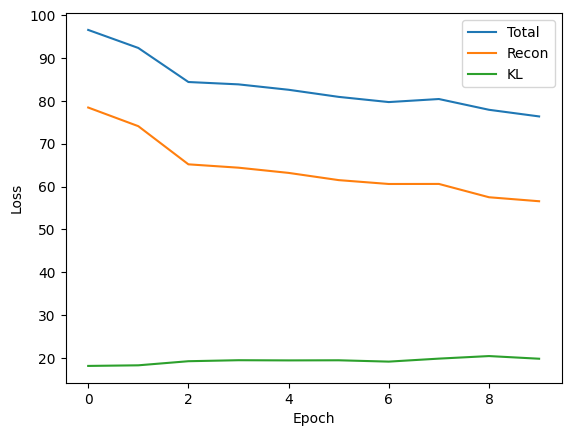

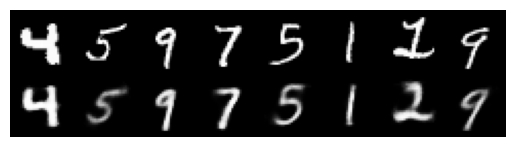

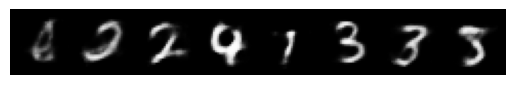

In [1]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(data, batch_size=128, shuffle=True)

# --- VAE ---
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400),
            nn.ReLU()
        )
        self.mu = nn.Linear(400, latent_dim)
        self.logvar = nn.Linear(400, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

vae = VAE(latent_dim=10).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (recon_loss + kl_loss) / x.size(0), recon_loss / x.size(0), kl_loss / x.size(0)

# --- Training ---
losses, recons, kls = [], [], []
for epoch in range(10):
    for x, _ in loader:
        x = x.to(device)
        recon, mu, logvar = vae(x)
        loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item()); recons.append(recon_l.item()); kls.append(kl_l.item())
    print(f"Epoch {epoch+1}: total={loss.item():.2f}, recon={recon_l.item():.2f}, KL={kl_l.item():.2f}")

# --- Plot loss curves ---
plt.plot(losses, label='Total'); plt.plot(recons, label='Recon'); plt.plot(kls, label='KL')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

# --- Visualize reconstructions ---
vae.eval()
with torch.no_grad():
    x, _ = next(iter(loader))
    x = x.to(device)[:8]
    recon, _, _ = vae(x)
    grid = torch.cat((x.cpu(), recon.cpu()))
    grid = utils.make_grid(grid, nrow=8, normalize=True)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()

# --- Latent space interpolation ---
with torch.no_grad():
    z = torch.randn(8, 10, device=device)
    samples = (vae.decode(z).cpu() + 1) / 2
    grid = utils.make_grid(samples, nrow=8)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()




### 🧩 **1. Reconstruction Loss**

**What it is:**
Measures **how well the decoder can rebuild the original image** from the latent code `z`.

**Intuition:**
You feed an image → it gets encoded → decoded → compare output vs input.
If the network perfectly “remembers” details, reconstruction loss is low.

**Mathematically (using MSE or BCE):**

Reconstruction Loss=∣∣x−x^∣∣2or−xlog(x^)−(1−x)log(1−x^)

This term **forces the model to capture visual fidelity** — to make outputs look like real data.

---

### 🌌 **2. KL Divergence (Kullback–Leibler term)**

**What it is:**
Measures how much the **learned latent distribution** (μ, σ from encoder) differs from a **standard normal distribution** ( N(0,1) ).

**Intuition:**
Without this, each image could encode anywhere in latent space — disorganized and discontinuous.
The KL term **pulls all latent encodings toward a smooth, centered Gaussian**, so that:

* Nearby z’s decode into similar outputs.
* You can sample random z ~ N(0,1) and get valid images.

**Formula:**

DKL​(q(z∣x)∣∣N(0,1))=21​∑(μ2+σ2−logσ2−1)

**Effect:** encourages structure and continuity in latent space.

---

### ⚖️ **Total Loss = Reconstruction + KL**

[
\mathcal{L} = \text{ReconLoss} + \beta \times \text{KL}
]

* The **reconstruction term** teaches “detail memory.”
* The **KL term** teaches “distribution smoothness.”
* β (usually 1) controls the trade-off:

  * ↑ β → smoother latent space, worse reconstructions
  * ↓ β → sharper reconstructions, less generalization

---

So:

* **Reconstruction** = “How close is my output to the input?”
* **KL** = “How well-behaved is my latent space?”
  Both together make the VAE capable of *learning and generating* new coherent data.


1) Core (10 min)
Task: Change latent dimension from 10 → 2 and plot reconstructed digits.
Hint: Low-dimensional z allows you to visualize latent space (scatter by label).

Epoch 1: total=159.63, recon=154.60, KL=5.03
Epoch 2: total=156.70, recon=150.74, KL=5.97
Epoch 3: total=160.33, recon=154.81, KL=5.52
Epoch 4: total=138.12, recon=131.79, KL=6.33
Epoch 5: total=142.43, recon=136.23, KL=6.20
Epoch 6: total=131.05, recon=124.77, KL=6.28
Epoch 7: total=136.22, recon=130.31, KL=5.91
Epoch 8: total=129.80, recon=123.40, KL=6.40
Epoch 9: total=140.16, recon=133.99, KL=6.17
Epoch 10: total=139.21, recon=133.09, KL=6.12


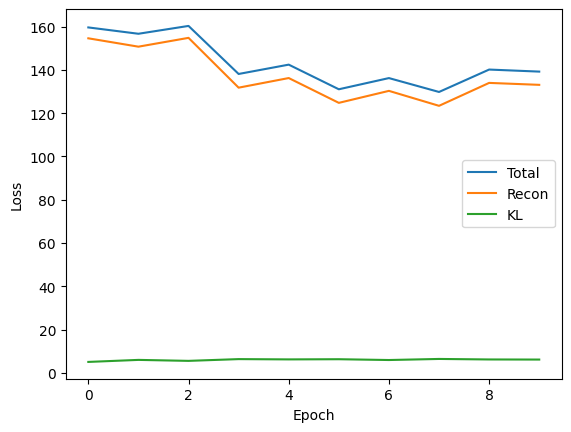

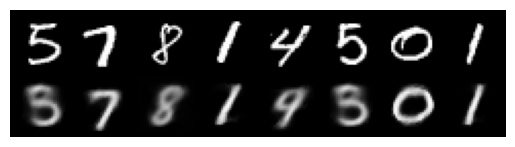

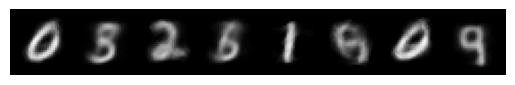

In [3]:
vae = VAE(latent_dim=2).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)


# --- Training ---
losses, recons, kls = [], [], []
for epoch in range(10):
    for x, _ in loader:
        x = x.to(device)
        recon, mu, logvar = vae(x)
        loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item()); recons.append(recon_l.item()); kls.append(kl_l.item())
    print(f"Epoch {epoch+1}: total={loss.item():.2f}, recon={recon_l.item():.2f}, KL={kl_l.item():.2f}")

# --- Plot loss curves ---
plt.plot(losses, label='Total'); plt.plot(recons, label='Recon'); plt.plot(kls, label='KL')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

# --- Visualize reconstructions ---
vae.eval()
with torch.no_grad():
    x, _ = next(iter(loader))
    x = x.to(device)[:8]
    recon, _, _ = vae(x)
    grid = torch.cat((x.cpu(), recon.cpu()))
    grid = utils.make_grid(grid, nrow=8, normalize=True)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()

# --- Latent space interpolation ---
with torch.no_grad():
    z = torch.randn(8, 2, device=device)
    samples = (vae.decode(z).cpu() + 1) / 2
    grid = utils.make_grid(samples, nrow=8)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()

Reconstrauction is worst but embeddings become plottable in 2D

2) Practice (15 min)
Task: Replace MSELoss with BCEWithLogitsLoss.
Hint: Binary cross-entropy is often better for 0–1 pixel data.

Epoch 1: total=129.44, recon=112.56, KL=16.88
Epoch 2: total=125.74, recon=108.79, KL=16.95
Epoch 3: total=118.70, recon=101.23, KL=17.47
Epoch 4: total=116.73, recon=99.39, KL=17.35
Epoch 5: total=115.07, recon=97.19, KL=17.88
Epoch 6: total=114.84, recon=96.98, KL=17.86
Epoch 7: total=114.77, recon=96.57, KL=18.20
Epoch 8: total=114.39, recon=96.22, KL=18.17
Epoch 9: total=112.56, recon=94.42, KL=18.14
Epoch 10: total=113.41, recon=95.32, KL=18.09


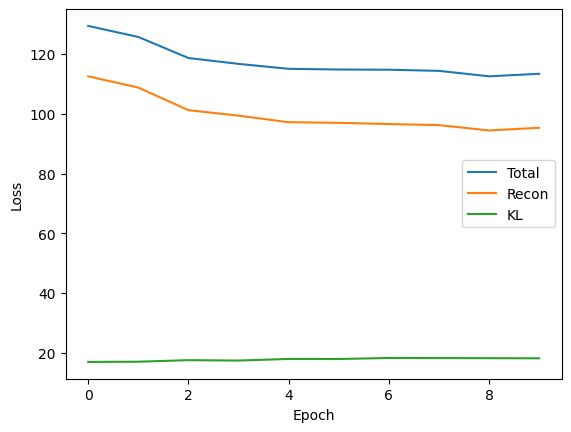

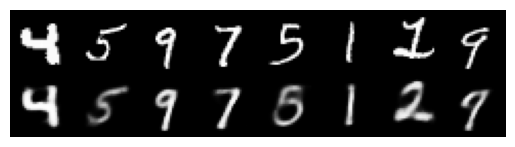

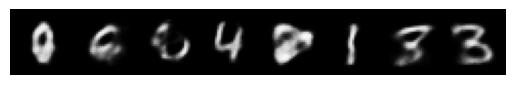

In [5]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# Data  ⟵ BCE needs targets in [0,1]
transform = transforms.Compose([
    transforms.ToTensor()          # <-- removed Normalize((0.5,), (0.5,))
])
data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(data, batch_size=128, shuffle=True)

# --- VAE ---
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400),
            nn.ReLU()
        )
        self.mu = nn.Linear(400, latent_dim)
        self.logvar = nn.Linear(400, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784)     # <-- no Tanh; produce logits
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        logits = self.decoder(z)                 # logits
        return logits.view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_logits = self.decode(z)            # logits
        return recon_logits, mu, logvar

vae = VAE(latent_dim=10).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# --- BCE-with-Logits loss ---
bce_logits = nn.BCEWithLogitsLoss(reduction='sum')

def vae_loss(recon_logits, x, mu, logvar, beta=1.0):
    # recon term (per-batch sum -> average per sample)
    recon_loss = bce_logits(recon_logits, x)
    # KL(q(z|x) || N(0,1))
    kl_loss = 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar)
    bsz = x.size(0)
    return (recon_loss + beta * kl_loss) / bsz, recon_loss / bsz, kl_loss / bsz

# --- Training ---
losses, recons, kls = [], [], []
for epoch in range(10):
    vae.train()
    for x, _ in loader:
        x = x.to(device)
        recon_logits, mu, logvar = vae(x)
        loss, recon_l, kl_l = vae_loss(recon_logits, x, mu, logvar)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item()); recons.append(recon_l.item()); kls.append(kl_l.item())
    print(f"Epoch {epoch+1}: total={loss.item():.2f}, recon={recon_l.item():.2f}, KL={kl_l.item():.2f}")

# --- Plot loss curves ---
plt.plot(losses, label='Total'); plt.plot(recons, label='Recon'); plt.plot(kls, label='KL')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

# --- Visualize reconstructions ---
vae.eval()
with torch.no_grad():
    x, _ = next(iter(loader))
    x = x.to(device)[:8]
    recon_logits, _, _ = vae(x)
    recon = torch.sigmoid(recon_logits)          # <-- turn logits into [0,1] for viewing
    grid = torch.cat((x.cpu(), recon.cpu()))
    grid = utils.make_grid(grid, nrow=8, normalize=True)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()

# --- Latent space samples (decode logits -> sigmoid) ---
with torch.no_grad():
    z = torch.randn(8, 10, device=device)
    samples_logits = vae.decode(z).cpu()
    samples = torch.sigmoid(samples_logits)      # <-- map to [0,1]
    grid = utils.make_grid(samples, nrow=8)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()


3) Stretch (optional)
Task: Vary β in the loss (weight on KL term, e.g. β=0.5 or 2).
Hint: High β forces more structured latent space, lower β improves recon.

Epoch 1: total=137.25, recon=113.86, KL=11.69
Epoch 2: total=130.97, recon=105.09, KL=12.94
Epoch 3: total=132.30, recon=106.84, KL=12.73
Epoch 4: total=128.39, recon=102.63, KL=12.88
Epoch 5: total=132.82, recon=104.79, KL=14.02
Epoch 6: total=129.73, recon=102.91, KL=13.41
Epoch 7: total=131.92, recon=103.60, KL=14.16
Epoch 8: total=132.59, recon=103.67, KL=14.46
Epoch 9: total=123.73, recon=96.37, KL=13.68
Epoch 10: total=123.60, recon=95.77, KL=13.91


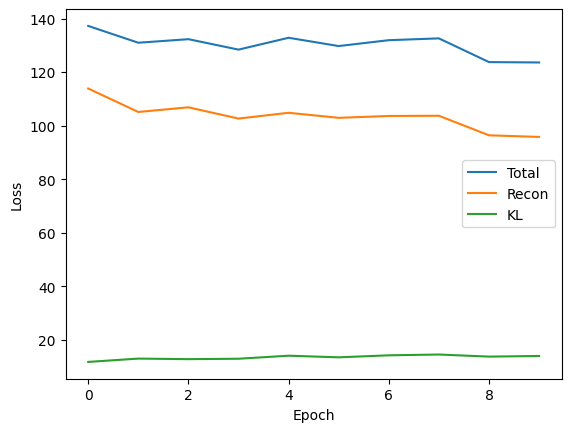

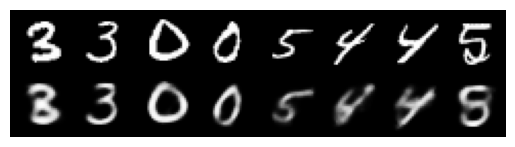

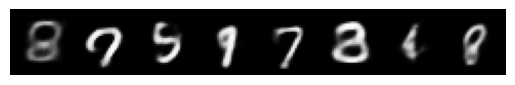

In [6]:
vae = VAE(latent_dim=10).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

# --- BCE-with-Logits loss ---
bce_logits = nn.BCEWithLogitsLoss(reduction='sum')

def vae_loss(recon_logits, x, mu, logvar, beta=1.0):
    # recon term (per-batch sum -> average per sample)
    recon_loss = bce_logits(recon_logits, x)
    # KL(q(z|x) || N(0,1))
    kl_loss = 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar)
    bsz = x.size(0)
    return (recon_loss + beta * kl_loss) / bsz, recon_loss / bsz, kl_loss / bsz

# --- Training ---
losses, recons, kls = [], [], []
for epoch in range(10):
    vae.train()
    for x, _ in loader:
        x = x.to(device)
        recon_logits, mu, logvar = vae(x)
        beta = 2
        loss, recon_l, kl_l = vae_loss(recon_logits, x, mu, logvar, beta)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item()); recons.append(recon_l.item()); kls.append(kl_l.item())
    print(f"Epoch {epoch+1}: total={loss.item():.2f}, recon={recon_l.item():.2f}, KL={kl_l.item():.2f}")

# --- Plot loss curves ---
plt.plot(losses, label='Total'); plt.plot(recons, label='Recon'); plt.plot(kls, label='KL')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

# --- Visualize reconstructions ---
vae.eval()
with torch.no_grad():
    x, _ = next(iter(loader))
    x = x.to(device)[:8]
    recon_logits, _, _ = vae(x)
    recon = torch.sigmoid(recon_logits)          # <-- turn logits into [0,1] for viewing
    grid = torch.cat((x.cpu(), recon.cpu()))
    grid = utils.make_grid(grid, nrow=8, normalize=True)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()

# --- Latent space samples (decode logits -> sigmoid) ---
with torch.no_grad():
    z = torch.randn(8, 10, device=device)
    samples_logits = vae.decode(z).cpu()
    samples = torch.sigmoid(samples_logits)      # <-- map to [0,1]
    grid = utils.make_grid(samples, nrow=8)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()

Mini-Challenge (≤40 min)

Goal: Train a small VAE for 20 epochs and show reconstructed vs generated digits.
Acceptance Criteria:

Three loss curves (total, recon, KL) plotted.

Grid comparing input vs reconstruction.

Grid of random samples from latent space.

Short note (≤3 lines): how latent dim and KL balance affect output quality.

Epoch 1: total=96.56, recon=78.45, KL=18.12
Epoch 2: total=92.35, recon=74.09, KL=18.26
Epoch 3: total=84.40, recon=65.18, KL=19.22
Epoch 4: total=83.85, recon=64.40, KL=19.45
Epoch 5: total=82.59, recon=63.18, KL=19.41
Epoch 6: total=80.93, recon=61.50, KL=19.44
Epoch 7: total=79.72, recon=60.60, KL=19.12
Epoch 8: total=80.43, recon=60.61, KL=19.82
Epoch 9: total=77.92, recon=57.50, KL=20.42
Epoch 10: total=76.37, recon=56.57, KL=19.80
Epoch 11: total=69.05, recon=50.05, KL=19.00
Epoch 12: total=69.47, recon=48.61, KL=20.86
Epoch 13: total=73.93, recon=54.36, KL=19.57
Epoch 14: total=74.30, recon=53.95, KL=20.35
Epoch 15: total=71.80, recon=51.06, KL=20.74
Epoch 16: total=69.31, recon=49.46, KL=19.84
Epoch 17: total=73.74, recon=53.38, KL=20.36
Epoch 18: total=70.48, recon=50.21, KL=20.27
Epoch 19: total=72.54, recon=51.95, KL=20.60
Epoch 20: total=74.25, recon=54.14, KL=20.11


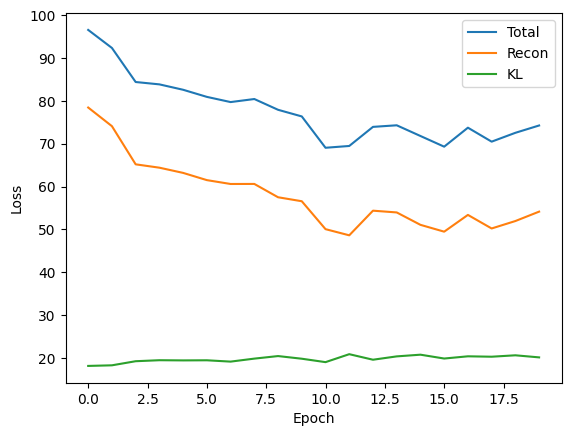

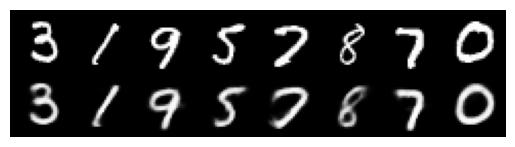

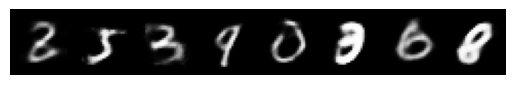

In [7]:
# Setup
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
loader = torch.utils.data.DataLoader(data, batch_size=128, shuffle=True)

# --- VAE ---
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400),
            nn.ReLU()
        )
        self.mu = nn.Linear(400, latent_dim)
        self.logvar = nn.Linear(400, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Tanh()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

vae = VAE(latent_dim=10).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (recon_loss + kl_loss) / x.size(0), recon_loss / x.size(0), kl_loss / x.size(0)

# --- Training ---
losses, recons, kls = [], [], []
for epoch in range(20):
    for x, _ in loader:
        x = x.to(device)
        recon, mu, logvar = vae(x)
        loss, recon_l, kl_l = vae_loss(recon, x, mu, logvar)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item()); recons.append(recon_l.item()); kls.append(kl_l.item())
    print(f"Epoch {epoch+1}: total={loss.item():.2f}, recon={recon_l.item():.2f}, KL={kl_l.item():.2f}")

# --- Plot loss curves ---
plt.plot(losses, label='Total'); plt.plot(recons, label='Recon'); plt.plot(kls, label='KL')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

# --- Visualize reconstructions ---
vae.eval()
with torch.no_grad():
    x, _ = next(iter(loader))
    x = x.to(device)[:8]
    recon, _, _ = vae(x)
    grid = torch.cat((x.cpu(), recon.cpu()))
    grid = utils.make_grid(grid, nrow=8, normalize=True)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()

# --- Latent space interpolation ---
with torch.no_grad():
    z = torch.randn(8, 10, device=device)
    samples = (vae.decode(z).cpu() + 1) / 2
    grid = utils.make_grid(samples, nrow=8)
plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()


Latent dim=10 is a good balance: smaller dims sharpen reconstructions but reduce variety; larger dims add diversity but can overfit.
The KL term regularizes z toward N(0,1); more KL (higher weight) smooths latent space and improves interpolation, but can blur reconstructions.

Notes / Key Takeaways

VAEs learn the data distribution directly via probability, not competition.

The KL term regularizes latent space to follow N(0,1).

Reparameterization trick allows gradients to flow through sampling.

Latent space structure → interpretable, controllable generation.

β controls the trade-off: realism vs disentanglement.

Reflection

Why does the KL divergence prevent overfitting in VAEs?

What happens if we remove the random noise in the reparameterization?

1. Why does the KL divergence prevent overfitting in VAEs?
The KL term forces the latent distribution  q(z∣x) to stay close to a simple prior N(0,1).
This prevents the encoder from memorizing each training example, encouraging it to learn general, smooth latent features instead — reducing overfitting and improving generalization.

1. What happens if we remove the random noise in the reparameterization?
Without the noise term ϵ, the encoder would always produce the same latent vector for each input.
The model would act like a plain autoencoder — it could reconstruct perfectly but wouldn’t learn a probabilistic latent space, so it couldn’t sample or generate new data.